# Lab 06 — Neural Networks: MLP for Fraud Detection

**DSA 8401 — Applied Machine Learning**

### Learning goals
By the end of this lab you should be able to:
1. Explain why neural networks need scaled features.
2. Build a simple MLP for binary classification.
3. Use early stopping and class weights.
4. Evaluate an imbalanced classifier with **PR-AUC**.
5. Choose a decision threshold using the validation set.
6. Evaluate the final model on an out-of-time test set.

**Core question:** Can a simple neural network compete with a tree-based model on tabular fraud data?

pip install keras , tensorflow

In [17]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

SEED = 42
keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.18.0


In [3]:
# Load the cleaned, feature-engineered data
df = pd.read_csv(
    r"C:\Users\Lbundi\Desktop\Strathmore Lectures\AML YR 26\Data\CleanedFeaturesFromLoan.csv",
    parse_dates=["txn_dt"],
)

In [4]:
df.head(3)

,txn_dt,abs_amount,log_amount,is_debit,balance_after,log_balance,risk_score,hour,day_of_week,day_of_month,month,is_weekend,is_night,has_gps,gps_lat,gps_lon,txn_type_enc,region_enc,segment_enc,is_fraud
0,2026-06-30 14:24:19,1329.0,7.192934,1,8123.0,9.002578,0.259686,14,1,30,6,0,0,0,0.00000,0.00000,6,4,2,0
1,2026-01-29 13:17:00,289.0,5.669881,1,6322.0,8.751949,0.000000,13,3,29,1,0,0,1,1.77470,34.70915,6,6,2,0
2,2025-09-16 00:55:00,1571.0,7.360104,0,15237.0,9.631548,1.000000,0,1,16,9,0,1,1,-3.74336,33.67018,5,0,2,1


In [6]:
# Load the cleaned, feature-engineered data
df = pd.read_csv(
    r"C:\Users\Lbundi\Desktop\Strathmore Lectures\AML YR 26\Data\CleanedFeaturesFromLoan.csv",
    parse_dates=["txn_dt"],
)

feature_cols = [
    "abs_amount", "log_amount", "is_debit",
    "balance_after", "log_balance", "risk_score",
    "hour", "day_of_week", "day_of_month", "month",
    "is_weekend", "is_night", "has_gps",
    "gps_lat", "gps_lon",
    "txn_type_enc", "region_enc", "segment_enc",
]

print(f"Rows: {len(df):,}")
print("Number of features:", len(feature_cols))
print("Date range:", df["txn_dt"].min(), "to", df["txn_dt"].max())
print("Fraud rate:", f"{df['is_fraud'].mean():.2%}")
df.head()

Rows: 183,600
Number of features: 18
Date range: 2025-02-06 00:46:00 to 2026-07-31 22:11:42
Fraud rate: 8.40%


,txn_dt,abs_amount,log_amount,is_debit,balance_after,log_balance,risk_score,hour,day_of_week,day_of_month,month,is_weekend,is_night,has_gps,gps_lat,gps_lon,txn_type_enc,region_enc,segment_enc,is_fraud
0,2026-06-30 14:24:19,1329.0,7.192934,1,8123.0,9.002578,0.259686,14,1,30,6,0,0,0,0.00000,0.00000,6,4,2,0
1,2026-01-29 13:17:00,289.0,5.669881,1,6322.0,8.751949,0.000000,13,3,29,1,0,0,1,1.77470,34.70915,6,6,2,0
2,2025-09-16 00:55:00,1571.0,7.360104,0,15237.0,9.631548,1.000000,0,1,16,9,0,1,1,-3.74336,33.67018,5,0,2,1
3,2026-04-07 11:21:00,599.0,6.396930,1,3322.0,8.108623,0.704212,11,1,7,4,0,0,0,0.00000,0.00000,6,1,2,0
4,2025-12-20 11:05:00,1307.0,7.176255,1,2168.0,7.682022,0.000000,11,5,20,12,1,0,1,0.08284,29.02835,3,7,2,0


## 2. Create the temporal train / validation / test split

The model must learn from the past and be evaluated on the future.

In [7]:
valid = df["txn_dt"].notna()

train_mask = (df["txn_dt"] < "2026-02-01") & valid

val_mask   = ((df["txn_dt"] >= "2026-02-01") & (df["txn_dt"] < "2026-05-01") & valid )

test_mask  = (df["txn_dt"] >= "2026-05-01") & valid

X_train = df.loc[train_mask, feature_cols].astype(float).values
y_train = df.loc[train_mask, "is_fraud"].astype(int).values

X_val = df.loc[val_mask, feature_cols].astype(float).values
y_val = df.loc[val_mask, "is_fraud"].astype(int).values

X_test = df.loc[test_mask, feature_cols].astype(float).values
y_test = df.loc[test_mask, "is_fraud"].astype(int).values

print(f"Train: {len(y_train):,} | fraud: {y_train.mean():.2%}")
print(f"Val:   {len(y_val):,} | fraud: {y_val.mean():.2%}")
print(f"Test:  {len(y_test):,} | fraud: {y_test.mean():.2%}")

Train: 122,000 | fraud: 8.45%
Val:   30,608 | fraud: 8.16%
Test:  30,992 | fraud: 8.48%


## 3. Scale the features

Neural networks learn using weighted sums and gradient descent. Large feature scales can dominate the optimisation.

We therefore:
1. **Fit** the scaler on training data.
2. **Transform** validation and test data using the same scaler.

Never fit the scaler on the full dataset.

In [18]:
scaler = StandardScaler()  # create an instance

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Training mean:", round(X_train_s.mean(), 3))
print("Training std: ", round(X_train_s.std(), 3))

Training mean: 0.0
Training std:  1.0


## 4. Build a simple MLP

Architecture:

**18 inputs → 32 ReLU → 16 ReLU → 1 Sigmoid**

- **ReLU:** hidden-layer activation
- **Sigmoid:** fraud probability
- **Binary cross-entropy:** loss
- **Adam:** optimiser

In [20]:
len(feature_cols)

18

In [21]:
model= keras.Sequential([
    
    # The first layer
    keras.Input(shape=(len(feature_cols),)),
    layers.Dense(64,activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(1,activation ='sigmoid')  #Binary 1,0  #Multiclass ~ softmax
])

In [ ]:
model = keras.Sequential([
    
    
        keras.Input(shape=(len(feature_cols),)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

In [22]:
model.compile(
    optimizer="adam",   # Gradient descent algos
    loss="binary_crossentropy",   #Loss Function mse
    metrics=[keras.metrics.AUC(name="pr_auc", curve="PR")]   # Metrics  
)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

$$\text{Parameters} = (\text{Input Size} \times \text{Units}) + \text{Units} = (\text{Input Size} + 1) \times \text{Units}$$

---
- Dnse_6 (Dense) — 608 Parameters
- Input Size: 18 
- Output Units: 32
- Weights: $18 \times 32 = 576$
- Biases: $32$
- Total: $576 + 32 = \mathbf{608}$

---

- dense_7 (Dense) — 528 Parameters
- Input Size: 32 (from the output of dense_6)
- Output Units: 16
- Weights: $32 \times 16 = 512$
- Biases: $16$Total: $512 + 16 = \mathbf{528}$

---

- Input Size: 16 (from the output of dense_7)
- Output Units: 1
- Weights: $16 \times 1 = 16$
- Biases: $1$Total: $16 + 1 = \mathbf{17}$

## 5. Train with early stopping

We monitor **validation PR-AUC**, because fraud detection is an imbalanced classification problem.

Early stopping prevents unnecessary training and helps control overfitting.

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
                        monitor="val_pr_auc",
                        mode="max",
                        patience=8,
                        restore_best_weights=True
                    )

history = model.fit(
                    X_train_s,
                    y_train,
                    validation_data=(X_val_s, y_val),
                    epochs=60,
                    batch_size=512,
                    callbacks=[early_stop]
                )

Epoch 1/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3534 - pr_auc: 0.1144 - val_loss: 0.1739 - val_pr_auc: 0.5446
Epoch 2/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1710 - pr_auc: 0.5800 - val_loss: 0.1622 - val_pr_auc: 0.5966
Epoch 3/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1631 - pr_auc: 0.6188 - val_loss: 0.1596 - val_pr_auc: 0.6149
Epoch 4/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1606 - pr_auc: 0.6280 - val_loss: 0.1582 - val_pr_auc: 0.6231
Epoch 5/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1593 - pr_auc: 0.6322 - val_loss: 0.1575 - val_pr_auc: 0.6268
Epoch 6/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1586 - pr_auc: 0.6356 - val_loss: 0.1569 - val_pr_auc: 0.6285
Epoch 7/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1580 - pr_auc: 0.6381 - val_loss: 0.1566 - val_pr_auc: 0.6298
Epoch 8/60
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1576 - pr_auc: 0.6397 - val_loss: 0.1563 - val_pr_auc: 0.6308
Epoch 9/

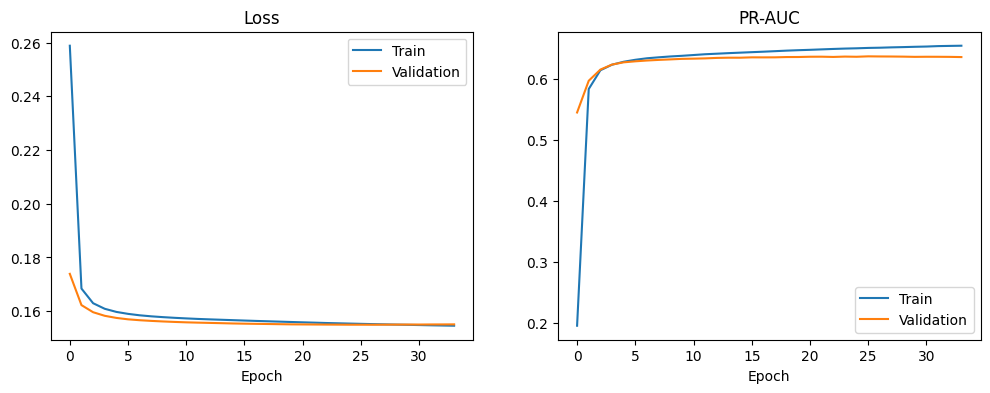

In [69]:
h = history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(h["loss"], label="Train")
plt.plot(h["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h["pr_auc"], label="Train")
plt.plot(h["val_pr_auc"], label="Validation")
plt.title("PR-AUC")
plt.xlabel("Epoch")
plt.legend()

plt.show()

## 6. Evaluate the model on validation data

**PR-AUC** is our main metric.

The random baseline is approximately the fraud rate.

In [70]:
p_val = model.predict(X_val_s, verbose=0).ravel()

val_pr_auc = average_precision_score(y_val, p_val)
val_roc_auc = roc_auc_score(y_val, p_val)

print(f"Validation PR-AUC : {val_pr_auc:.4f}")
print(f"Validation ROC-AUC: {val_roc_auc:.4f}")
print(f"Random PR-AUC     : {y_val.mean():.4f}")

Validation PR-AUC : 0.6363
Validation ROC-AUC: 0.9297
Random PR-AUC     : 0.0816


## 7. Summary

### What should you remember?

1. **Scale inputs** before training a neural network.
2. Fit preprocessing steps on **training data only**.
3. A simple MLP can be enough for a small tabular feature set.
4. Use **PR-AUC** rather than accuracy when the positive class is rare.
5. Use **early stopping** to control training and overfitting.
